In [ ]:
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
import numpy as np

%matplotlib inline

In [ ]:
from sklearn.model_selection import train_test_split

drive.mount('/content/drive')
datadir = "/content/drive/My Drive/Colab Notebooks/CS 441/final resources/" 

train_file_path = datadir + "train.csv"
test_file_path = datadir + "test.csv"

#reading the train and test csv files
train_df = pd.read_csv(train_file_path)
test_df = pd.read_csv(test_file_path)

# separating y-labels 
x_train = train_df.filter(items=['TotRmsAbvGrd']).to_numpy()
y_train = train_df.filter(items=['SalePrice']).to_numpy()

x_test = test_df.filter(items=['TotRmsAbvGrd']).to_numpy()
y_test = test_df.filter(items=['SalePrice']).to_numpy()

#split training dataset into train and validation sets
x_train_split, x_val, y_train_split, y_val = train_test_split(x_train, y_train, test_size=0.30)

print(x_train_split.shape, x_val.shape)
print(y_train_split.shape, y_val.shape)



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(1022, 1) (438, 1)
(1022, 1) (438, 1)


In [ ]:
x_train = train_df[['YearBuilt', 'TotalBsmtSF', 'GarageArea']]
y_train = train_df['SalePrice']
x_train_split, x_val, y_train_split, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state = 42)

rmse 0.27006494352948357
mae 0.15405750248956718


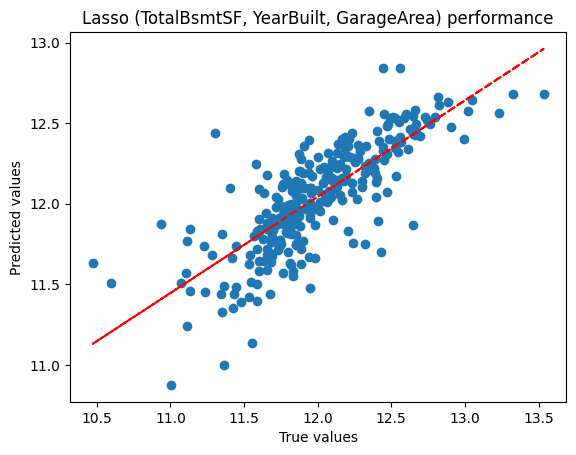

In [ ]:
#Lasso model
from sklearn.linear_model import Lasso
from sklearn.metrics import median_absolute_error

l = Lasso()
l.fit(x_train_split, y_train_split)
y_pred_lr = l.predict(x_val)

mean = np.square(np.subtract(np.log(y_val), np.log(y_pred_lr))).mean()
print ("rmse", np.sqrt(mean))
print("mae", median_absolute_error(np.log(y_val), np.log(y_pred_lr)))

# Fit a linear regression line to the data
z = np.polyfit(np.log(y_val), np.log(y_pred_lr), 1)
p = np.poly1d(z)

# Create a scatter plot of the data with the line of best fit
plt.scatter(np.log(y_val), np.log(y_pred_lr))
plt.plot(np.log(y_val), p(np.log(y_val)), 'r--')
plt.xlabel('True values')
plt.ylabel('Predicted values')
plt.title('Lasso (TotalBsmtSF, YearBuilt, GarageArea) performance')
plt.show()

rmse 0.270064946209029
mae 0.1540574945747597


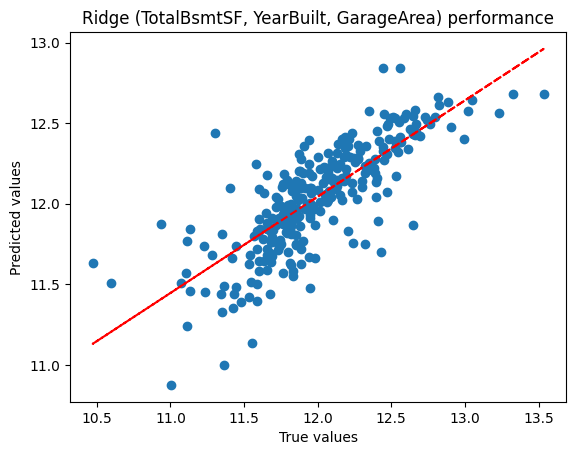

In [ ]:
#Ridge Model
from sklearn.linear_model import LogisticRegression, Ridge

l_reg = Ridge()
l_reg.fit(x_train_split, y_train_split)
y_pred = l_reg.predict(x_val)

mean = np.square(np.subtract(np.log(y_val), np.log(y_pred))).mean()
print ("rmse", np.sqrt(mean))
print("mae", median_absolute_error(np.log(y_val), np.log(y_pred)))

# Fit a linear regression line to the data
z = np.polyfit(np.log(y_val), np.log(y_pred), 1)
p = np.poly1d(z)

# Create a scatter plot of the data with the line of best fit
plt.scatter(np.log(y_val), np.log(y_pred))
plt.plot(np.log(y_val), p(np.log(y_val)), 'r--')
plt.xlabel('True values')
plt.ylabel('Predicted values')
plt.title('Ridge (TotalBsmtSF, YearBuilt, GarageArea) performance')
plt.show()

rmse 0.29167920323523155
mae 0.14298178184704113


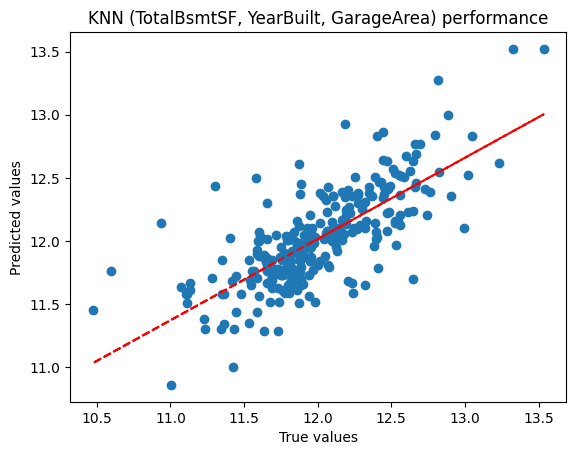

In [ ]:
#KNN Model
from sklearn.neighbors import KNeighborsClassifier

neigh = KNeighborsClassifier(n_neighbors=1)
neigh.fit(x_train_split, y_train_split)
y_pred = neigh.predict(x_val)

mean = np.square(np.subtract(np.log(y_val), np.log(y_pred))).mean()
print ("rmse", np.sqrt(mean))
print("mae", median_absolute_error(np.log(y_val), np.log(y_pred)))

# Fit a linear regression line to the data
z = np.polyfit(np.log(y_val), np.log(y_pred), 1)
p = np.poly1d(z)

# Create a scatter plot of the data with the line of best fit
plt.scatter(np.log(y_val), np.log(y_pred))
plt.plot(np.log(y_val), p(np.log(y_val)), 'r--')
plt.xlabel('True values')
plt.ylabel('Predicted values')
plt.title('KNN (TotalBsmtSF, YearBuilt, GarageArea) performance')
plt.show()